# M6 - AML - Assignment 1

## GBM And LightGBM Boosting Methods

## Business Context:
The study analyzes direct marketing campaigns conducted by a Portuguese banking institution to promote term deposits.

The objective is to predict whether a client will subscribe to a term deposit based on demographic, financial, and campaign-related information.

This predictive modeling helps optimize marketing efforts, reduce campaign costs, and improve customer targeting efficiency.

## Dataset Description

* age – Client’s age (numeric)
* job – Type of job (categorical)
* marital – Marital status (categorical)
* education – Education level (categorical)
* default – Has credit in default? (yes/no)
* balance – Average yearly account balance (numeric)
* housing – Has housing loan? (yes/no)
* loan – Has personal loan? (yes/no)
* contact – Contact communication type (telephone/cellular/unknown)
* duration – Call duration in seconds (numeric)
* campaign – Number of contacts during this campaign
* y – Whether the client subscribed to a term deposit (yes/no → binary classification)

## Questions:

* Import the training dataset, perform basic checks and create dummy variables.
* Import the test dataset, apply the same preprocessing steps, and align feature columns with the training data.
* Build a Gradient Boosting (GBM) model using n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42 and evaluate using ROC-AUC.
* Build a LightGBM model using n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42 and evaluate using ROC-AUC.
* Compare two models using ROC curves and AUC scores.

In [187]:
import pandas as pd

train_df = pd.read_csv("Bank_Marketing_Train.csv")
train_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,198,1,no


In [188]:
train_df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
duration      int64
campaign      int64
y            object
dtype: object

In [189]:
train_df.describe()

,age,balance,duration,campaign
count,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,258.163080,2.763841
std,10.618762,3044.765829,257.527812,3.098021
min,18.000000,-8019.000000,0.000000,1.000000
25%,33.000000,72.000000,103.000000,1.000000
50%,39.000000,448.000000,180.000000,2.000000
75%,48.000000,1428.000000,319.000000,3.000000
max,95.000000,102127.000000,4918.000000,63.000000


In [190]:
train_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
duration     0
campaign     0
y            0
dtype: int64

In [191]:
test_df = pd.read_csv("Bank_Marketing_Test.csv")
test_df.head()

,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,79,1,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,220,1,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,185,1,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,199,4,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,226,1,no


In [192]:
test_df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
duration      int64
campaign      int64
y            object
dtype: object

In [193]:
test_df.describe()

,age,balance,duration,campaign
count,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,263.961292,2.793630
std,10.576211,3009.638142,259.856633,3.109807
min,19.000000,-3313.000000,4.000000,1.000000
25%,33.000000,69.000000,104.000000,1.000000
50%,39.000000,444.000000,185.000000,2.000000
75%,49.000000,1480.000000,329.000000,3.000000
max,87.000000,71188.000000,3025.000000,50.000000


In [194]:
test_df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
duration     0
campaign     0
y            0
dtype: int64

## Let's start to create dummy variables and align feature columns

In [195]:
X_train = pd.get_dummies(train_df.drop(columns="y"), drop_first=True)
y_train = train_df["y"].map({"no": 0, "yes": 1})

X_train.head()

,age,balance,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown
0,58,2143,261,1,False,False,False,True,False,False,...,True,False,False,True,False,False,True,False,False,True
1,44,29,151,1,False,False,False,False,False,False,...,False,True,True,False,False,False,True,False,False,True
2,33,2,76,1,False,True,False,False,False,False,...,True,False,True,False,False,False,True,True,False,True
3,47,1506,92,1,True,False,False,False,False,False,...,True,False,False,False,True,False,True,False,False,True
4,33,1,198,1,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True


In [196]:
X_test = pd.get_dummies(test_df.drop(columns="y"), drop_first=True)
y_test = test_df["y"].map({"no": 0, "yes": 1})

X_test = X_test.reindex(columns=X_train.columns, fill_value=0) # IMPORTANT: X_train used on reindex for alignment
X_test.head()

,age,balance,duration,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,default_yes,housing_yes,loan_yes,contact_telephone,contact_unknown
0,30,1787,79,1,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,33,4789,220,1,False,False,False,False,False,False,...,True,False,True,False,False,False,True,True,False,False
2,35,1350,185,1,False,False,False,True,False,False,...,False,True,False,True,False,False,True,False,False,False
3,30,1476,199,4,False,False,False,True,False,False,...,True,False,False,True,False,False,True,True,False,True
4,59,0,226,1,True,False,False,False,False,False,...,True,False,True,False,False,False,True,False,False,True


## Building a Gradient Boosting (GBM)

In [197]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

gbm = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

gbm.fit(X_train, y_train)
y_prob_gbm = gbm.predict_proba(X_test)[:, 1]

roc_auc_value_gbm = roc_auc_score(y_test, y_prob_gbm)
print("GBM ROC-AUC:", roc_auc_value_gbm)

GBM ROC-AUC: 0.8923063819577737


## Building a LightGBM Model

In [198]:
from lightgbm import LGBMClassifier

light_gbm = LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    verbose=-1,
    force_row_wise=True
)

light_gbm.fit(X_train, y_train)
y_prob_light_gbm = light_gbm.predict_proba(X_test)[:, 1]
roc_auc_value_light_gbm = roc_auc_score(y_test, y_prob_light_gbm)
print("LightGBM ROC-AUC:", roc_auc_value_light_gbm)

LightGBM ROC-AUC: 0.8935753358925144


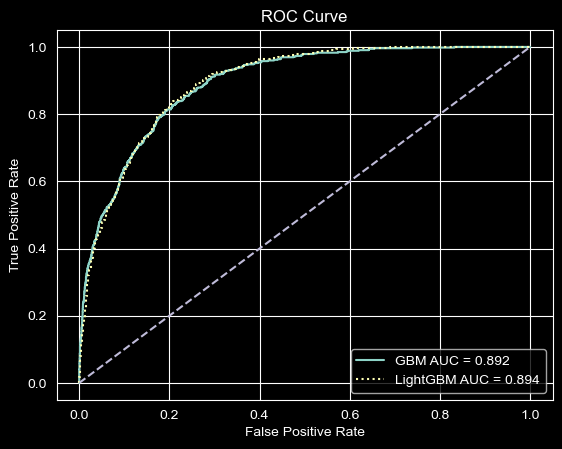

In [199]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_gbm, tpr_gbm, thresholds_gbm = roc_curve(y_test, y_prob_gbm)
fpr_light_gbm, tpr_light_gbm, thresholds_light_gbm = roc_curve(y_test, y_prob_light_gbm)

plt.figure()
plt.plot(fpr_gbm, tpr_gbm, label='GBM AUC = %0.3f' % roc_auc_value_gbm)
plt.plot(fpr_light_gbm, tpr_light_gbm, linestyle=':', label='LightGBM AUC = %0.3f' % roc_auc_value_light_gbm)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Since both models produced very similar ROC-AUC scores, the predictive performance difference between GBM and LightGBM was minimal in this assignment. This suggests that using the traditional GBM may not provide a meaningful advantage here, while LightGBM can be considered a more efficient alternative because it is generally faster and better suited for larger datasets.